In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load and scale to [0, 1]
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0
# Subsample for 2-hour lab runtime
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=10000, test_size=2000, random_state=42, stratify=y)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

TASK 1 Exploratory Visualization & Baseline Classifier
1.1 Sample Inspection: Reshape and plot a 2 × 5 grid showing one representative training image for
each digit class (0 through 9) with its corresponding ground-truth label.

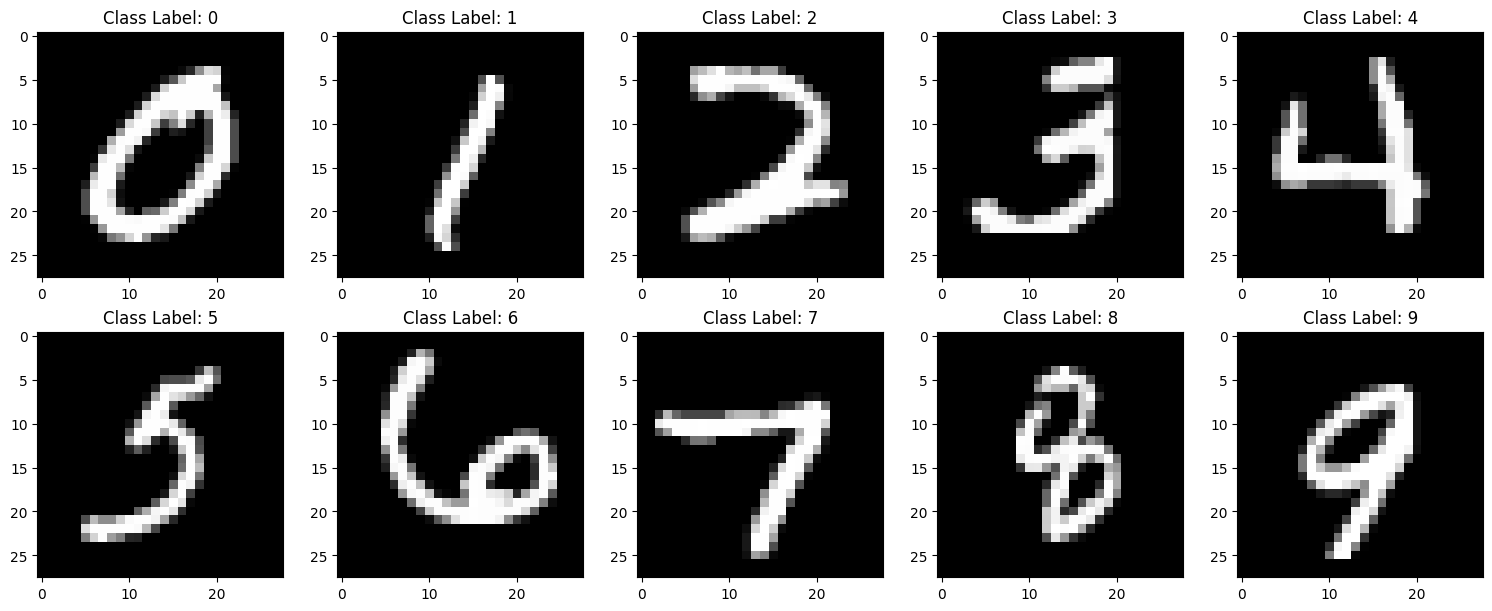

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rep = {}

for i in range(len(X_train)):
    if y_train[i] not in rep:
        rep[y_train[i]] = X_train[i]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), constrained_layout=True)
for i in range(2):
    for j in range(5):
        label = 5*i+j
        axes[i, j].imshow(rep[label].reshape(28, 28), cmap="gray")
        axes[i, j].set_title(f"Class Label: {label}")

1.2 Baseline Classifier Fitting: [CONSULT DOCS]
Look up the linear classification models in scikit-learn. Instantiate and fit a multinomial logistic
regression model on your training subset.
Which optimization solver is used by default? Did the model converge within default iterations, or did
you need to increase the iteration limit? Measure and report the training elapsed time and the overall
accuracy on your test subset.

In [3]:
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics
import time

multi_logreg = LogisticRegression(max_iter=1000)
starttime = time.perf_counter()
multi_logreg.fit(X_train, y_train)
print(f"Training Time: {time.perf_counter() - starttime} seconds")
y_pred = multi_logreg.predict(X_test)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")

Training Time: 5.914256264994037 seconds
Accuracy: 0.908


* By default, the lbfgs solver is used.
* No, the model did not converge within default(100) iterations. The iteration limit needed to be increased.

1.3 Error Diagnostics via Confusion Matrix: [CONSULT DOCS]Explore the evaluation metrics module in scikit-learn to compute and display a normalized confusion
matrix visualizer.
Question 1.3: Identify the two digit pairs exhibiting the highest mutual confusion rate. In your own
words try to explain why it might be the case?

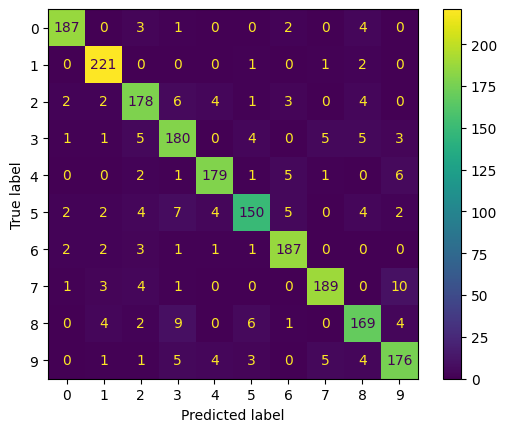

In [4]:
confMatrix = metrics.confusion_matrix(y_test, y_pred)
metrics.ConfusionMatrixDisplay(confMatrix).plot()

The digit pairs exhibiting the highest mutual confusion rate are (8,3) and (7,9). This means that 8 is being mistaken as 3 and 7 is being mistaken as 9. When the left part of 8 is not fully connected, it looks like the number 3. The upper part of 7 can look like a 9 with the curve not fully connected. This could be a reason why there is high mutual confusion between the two digits.

2.1 Downsampling Pipeline: [CONSULT DOCS]
Downsample all images in both X_train and X_test from their original 28 x 28 dimensions down to:
Downsample all images in both train and test sets to:
Resolution A: 14 × 14 pixels
Resolution B: 7 × 7 pixels
(Hint: Use skimage.transform.resize. Because each sample in X_train and X_test is stored as a flattened
784-dimensional vector, reshape each image back to (28, 28) before resizing, then flatten (.ravel()) it
back. You can apply this across the dataset using a loop or list comprehension:)

In [5]:
%pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
from skimage.transform import resize
# Example: downsample a single 1D image vector 'x' (shape: 784,) to 14x14
# resized_sample = resize(x.reshape(28, 28), (14, 14), anti_aliasing=True).ravel()
# To process the full split:
X_train_A = np.array([resize(img.reshape(28, 28), (14, 14), anti_aliasing=True).ravel() for img in X_train])
X_test_A = np.array([resize(img.reshape(28, 28), (14, 14), anti_aliasing=True).ravel() for img in X_test])

X_train_B = np.array([resize(img.reshape(28, 28), (7, 7), anti_aliasing=True).ravel() for img in X_train])
X_test_B = np.array([resize(img.reshape(28, 28), (7, 7), anti_aliasing=True).ravel() for img in X_test])

2.2 Resolution Comparison Experiment: Train identical logistic regression models on each resolution.
Note down the test accuracy of each.

In [7]:
time_taken = {}

multi_logreg_A = LogisticRegression(max_iter=1000)
multi_logreg_A.fit(X_train_A, y_train)
start = time.perf_counter()
y_pred_A = multi_logreg_A.predict(X_test_A)
time_taken["multi_logreg_14"] = time.perf_counter() - start
print(f"Accuracy(Resolution A): {metrics.accuracy_score(y_test, y_pred_A)}")

multi_logreg_B = LogisticRegression(max_iter=1000)
multi_logreg_B.fit(X_train_B, y_train)
y_pred_B = multi_logreg_B.predict(X_test_B)
print(f"Accuracy(Resolution B): {metrics.accuracy_score(y_test, y_pred_B)}")

Accuracy(Resolution A): 0.9125
Accuracy(Resolution B): 0.88


Question 2.3: When reducing the number of features by over 93% (784→49), how much accuracy did
the linear model lose? Why does a linear classifier remain relatively effective even when digits are
blurred?

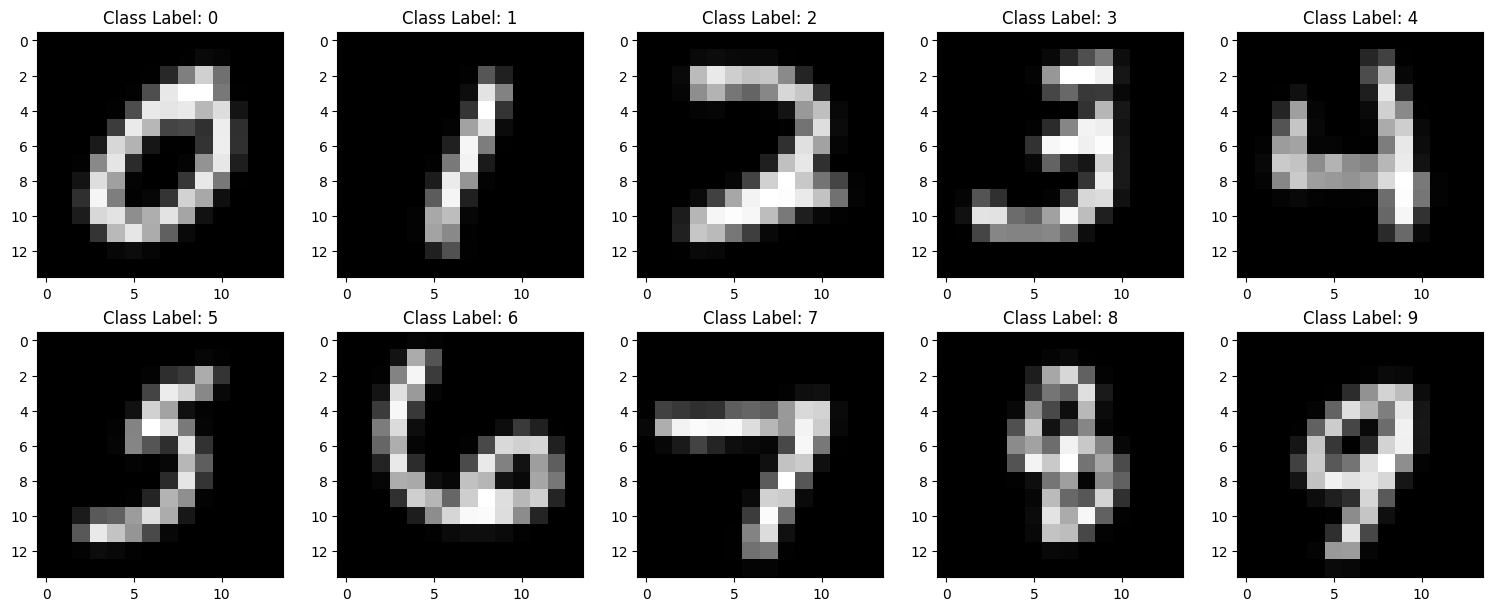

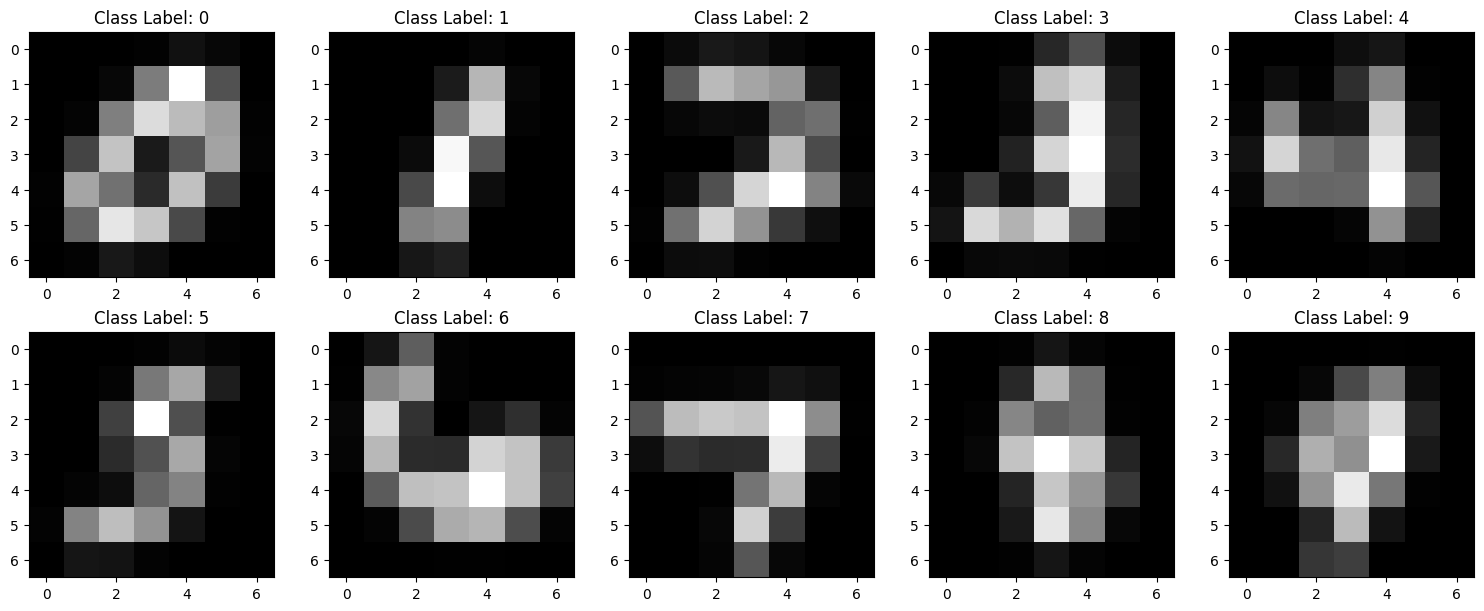

In [8]:
repA = {}

for i in range(len(X_train_A)):
    if y_train[i] not in repA:
        repA[y_train[i]] = X_train_A[i]
    if len(repA) >= 10:
        break

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), constrained_layout=True)
for i in range(2):
    for j in range(5):
        label = 5*i+j
        axes[i, j].imshow(repA[label].reshape(14, 14), cmap="gray")
        axes[i, j].set_title(f"Class Label: {label}")



repB = {}

for i in range(len(X_train_B)):
    if y_train[i] not in repB:
        repB[y_train[i]] = X_train_B[i]
    if len(repB) >= 10:
        break

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), constrained_layout=True)
for i in range(2):
    for j in range(5):
        label = 5*i+j
        axes[i, j].imshow(repB[label].reshape(7, 7), cmap="gray")
        axes[i, j].set_title(f"Class Label: {label}")

When reducing the number of features from 784 to 49, the accuracy of the model decreased from 90.8% to 88.0%. The linear classifier remained relatively effective even when digits are blurred because blurring preserves the shape of the digits and only removes the high-frequency noise.

TASK 3 Interpretability & Spatial Weight Map Visualization
Unlike black-box architectures, multinomial logistic regression produces direct linear weights that map
back to the input coordinate space.
3.1 Parameter Discovery: [CONSULT DOCS]
Check the documentation for your fitted logistic regression model. Identify the public attribute storing
the learned coefficient matrix.
* What is the attribute name and its array shape? What do the dimensions correspond to?
* Reshape each class's weight vector back into the original 28 × 28 2D image coordinates.

In [9]:
print(multi_logreg.coef_.shape)

(10, 784)


The attribute coef_ stores the coefficients of the fitted logistic regression model. Its shape is (10, 784) in this case. The dimensions correspond to the number of classes (10) and the number of features (784) in the training data.

In [10]:
weights = {}

for i in range(10):
    weights[i] = multi_logreg.coef_[i].reshape(28, 28)

3.2 Diverging Heatmap Visualization:
Plot all 10 weight vectors in a 2 × 5 subplot layout using a diverging colormap centered symmetrically
at zero (e.g., set vmin=-scale and vmax=scale, where scale=np.max(np.abs(weights))) along with a
colorbar.

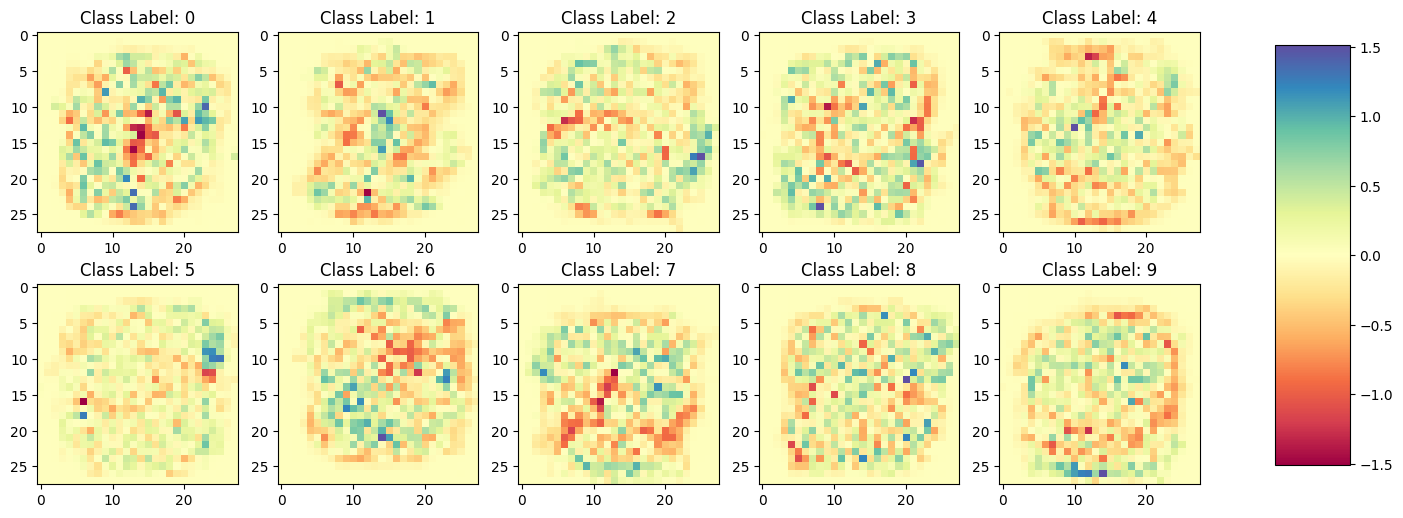

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
for i in range(2):
    for j in range(5):
        label = 5*i+j
        scale=np.max(np.abs(weights[label]))
        im = axes[i, j].imshow(weights[label], vmin=-scale, vmax=scale, cmap="Spectral")
        axes[i, j].set_title(f"Class Label: {label}")
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

Question 3.3 (Visualizing Decision Ambiguity):
Take the two most confused digits identified in Task 1.3. Compare their weight heatmaps side by side.
How does spatial overlap or cancellation between their weights explain why the model mistakes one
for the other?

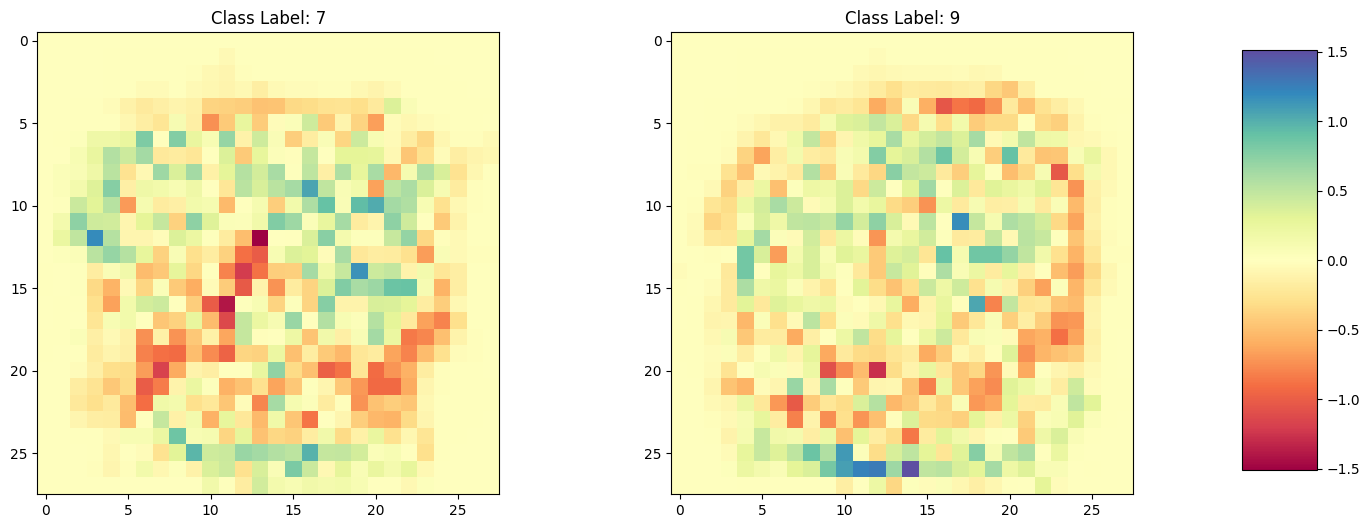

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
scale=np.max(np.abs(weights[7]))
im = axes[0].imshow(weights[7], vmin=-scale, vmax=scale, cmap="Spectral")
axes[0].set_title(f"Class Label: 7")
scale=np.max(np.abs(weights[9]))
im = axes[1].imshow(weights[9], vmin=-scale, vmax=scale, cmap="Spectral")
axes[1].set_title(f"Class Label: 9")
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

The weight heatmaps for the labels 7 and 9 are very similar. This explains why 7 is mistaken as 9.

TASK 4 Parametric vs. Non-Parametric Benchmark (k-NN)
4.1 Estimator Discovery: [CONSULT DOCS] Look up the k-Nearest Neighbors classification estimator
in scikit-learn. Fit a 3-NN model on the 14×14 downsampled dataset (do not run on 28×28 to avoid
long distance-computation delays).

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn_14 = KNeighborsClassifier(n_neighbors=3)
knn_14.fit(X_train_A, y_train)

start = time.perf_counter()
y_pred_14 = knn_14.predict(X_test_A)
time_taken["3nn_14"] = time.perf_counter() - start
print(f"Accuracy of 3nn_14: {metrics.accuracy_score(y_test, y_pred_14)}")

Accuracy of 3nn_14: 0.957


4.2 Benchmark: Measure and compare the test accuracy and test-set prediction latency (inference time
on the 2,000 test images) between Logistic Regression (14×14) and 3-NN (14×14).

In [14]:
df = pd.DataFrame({
    "Classification Method": [
        "Logistic Regression",
        "K-Nearest Neighbors (K=3)"
    ],
    "Test Accuracy": ["91.25%", "95.7%"],
    "Time Taken (s)": [time_taken["multi_logreg_14"],time_taken["3nn_14"]]
})

print(df)

       Classification Method Test Accuracy  Time Taken (s)
0        Logistic Regression        91.25%        0.001297
1  K-Nearest Neighbors (K=3)         95.7%        0.287042


Question 4.3: Express the test-time computational complexity of both algorithms in Big-O notation in
terms of training samples N and feature count d. Why is Logistic Regression faster for real-time
prediction? [Non Graded but to be attempted]

| Algorithm | Training Time Complexity | Prediction Time Complexity | Space Complexity |
| --- | --- | --- | --- |
| Logistic Regression | O(Nd) | O(d) | O(d) |
| K-Nearest Neighbors | O(1) | O(Nd) | O(Nd) |

Logistic Regression is faster for real time prediction because it doesn't depend on the number of training samples. This is especially useful for extremely large datasets.